# AutoML for Regression Model Screening

The following are the steps for using AutoML for a regression task:

_Note: Setting the flag for featurization= 'True' generates represents molecules using 5 representation techniques._ 

1. Requires an input pandas dataframe consisting of two columns:<br>
    * SMILES strings<br>
    * target property values<br>


2. If featurization = True, Molecules are represented as:<br>
    * Coulomb matrix<br>
    * RDKit Morgan (ECFP6 1024-bit) fingerprints<br>
    * MACCs keys<br>
    * RDKit hashed topological torsion<br>
    * RDKit molecular descriptors (all)<br>
    * Mordred molecular descriptors (currently using base Mordred)<br>


3. Screens through various regressor models:<br>
    * Single-core (runs regardless of multi_core value):
        * [Ridge](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html)<br>
        * [Lasso](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html)<br>
        * [SVR](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVR.html) (if n_datapoints<500)<br>
        * [ElasticNet](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ElasticNet.html)<br>
        * [DecisionTreeRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html)<br>
    * Multi-core(set multi_core=True):
        * [MLPRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPRegressor.html) (if n_datapoints<=500)<br>
        * [GradientBoostingRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingRegressor.html) (if n_datapoints<=500)<br>
        * [RandomForestRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html)<br>
        * [ChemML_MLP](https://hachmannlab.github.io/chemml/ipython_notebooks/ml_model.html) (if n_datapoints>500)<br>
        * (optional) [XGBRegressor](https://xgboost.readthedocs.io/en/latest/python/python_api.html)<br>
        * (optional) [LightGBM](https://lightgbm.readthedocs.io/en/stable/)

Yields 'n-best' models, with optimized hyperparamters.

The output_dir argument specifies a folder that will be created wherever the code is run from, containing the following directory tree:

<pre> &lt;output_dir&gt;/<br> |-- output.log<br> |-- scores.csv<br> |-- best_model/<br> |   |-- model.pkl # most non-MLP models<br> |   |-- model_chemml_model.json # MLP case (plus possible extra model files)<br> |   |-- scaler.pkl # present when scaler exists for chosen feature_key<br> |   |-- feature_order.json<br> |   |-- metadata.json<br> |-- .model_screener_artifacts/<br> |   |-- &lt;run_key_1&gt;/<br> |        |-- model.pkl # or MLP artifact files<br> |   |-- &lt;run_key_2&gt;/<br>... </pre>

## Load your data 

We are using ChemML's in-built dataset to demonstrate the minimum requirements to run AutoML.

In [ ]:
import pandas as pd
from chemml.datasets import load_organic_density

In [2]:
molecules, target, dragon_subset = load_organic_density()
df=pd.concat([molecules, target], axis=1)
df = df.sample(100, random_state=42)
df

,smiles,density_Kg/m3
361,c1scc(n1)c1ncc(s1)c1c(ccc2c1cccc2)c1cncs1,1328.35
73,S1CC(SC(C1)C1CCCC1)c1cocc1c1ccccc1,1143.80
374,N1CNC(NC1)c1sccc1C1(CSCCS1)c1cccs1,1351.33
155,c1nc(c(s1)c1nsnc1)c1csc(n1)c1cccs1,1466.57
104,Oc1ccc2c(c1c1cocc1)c(ccc2)c1ccccn1,1207.67
...,...,...
347,c1ccc(cn1)c1ncsc1c1scnc1c1ccc2c(c1)cccc2,1269.53
86,c1cnc(cn1)c1coc(c1)c1nccc(c1)c1cccc2c1cccc2,1209.81
75,OC1NCN(CN1)c1cccc2c1ccc(c2)C1CSCCS1,1282.86
438,Sc1cc2c(cc1c1ccc3c(c1)cccc3)cccc2C1CCCC1,1122.68


## Run autoML for a regression task

Since we have not provided any feature set, we can use AutoML's in-built featurization to screen through feature representations and find the most suitable feature set for our data.

In [3]:
from chemml.autoML import ModelScreener
MS = ModelScreener(df, target="density_Kg/m3", featurization=True, smiles="smiles", 
                   screener_type="regressor", output_dir="automl_results")
scores = MS.screen_models(n_best=10, multi_core=False)



-------------------------ChemML AutoML Model Screening-------------------------

-------------------------Model screening started at Mon Aug 10 09:50:30 2026-------------------------


Featurization is set to True. Generating molecular representations for SMILES strings...


Converting SMILES to ChemML Molecule objects...



Converting SMILES to ChemML Molecule objects: 100%|██████████| 100/100 [00:07<00:00, 13.88it/s]



Generating Coulomb matrix representation...

featurizing molecules in batches of 6 ...
100/100 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22s 224ms/step
Merging batch features ...    [DONE]

Generating RDKit fingerprint representations...


Generating RDKit descriptor representations...



Calculating RDKit descriptors: 100%|██████████| 100/100 [00:02<00:00, 48.75it/s]



Generating Mordred descriptor representations...



100%|██████████| 100/100 [00:05<00:00, 16.91it/s]



Cleaning feature sets to remove constant, highly correlated, and low-variance features...

Feature set 'CoulombMatrix' cleaned: 26 features retained.

Feature set 'morganfingerprints_radius3' cleaned: 247 features retained.

Feature set 'MACCS_radius3' cleaned: 48 features retained.

Feature set 'hashedtopologicaltorsion_radius3' cleaned: 82 features retained.

Feature set 'hashedatompair_radius3' cleaned: 416 features retained.

Feature set 'rdkit_descriptors' cleaned: 92 features retained.

Feature set 'mord_descriptors' cleaned: 411 features retained.


-------------------------Run parameters-------------------------
  Featurization: True
  Multi_core: False
  Screener_type: regressor
  Number of datapoints: 100
  Note: Dataset <= 500 samples; MLP is excluded from screening due to inefficiency.

split done!
Single-core complete 


------------------------- Screening complete for feature set CoulombMatrix, time taken: 17.042 seconds -------------------------

split done!
Single-core

In [4]:
scores

,ME,MAE,MSE,RMSE,MSLE,RMSLE,MAPE,MaxAPE,RMSPE,MPE,MaxAE,deltaMaxE,r_squared,time(seconds),Model,parameters,Feature,run_key
30,-1.201041,6.709837,62.965976,7.935110,0.000040,0.006301,0.530823,1.126562,0.631787,-0.109486,12.571413,24.286619,0.990585,1.444629,Ridge,"{'alpha': 19.700000000000003, 'copy_X': True, ...",mord_descriptors,Ridge_mord_descriptors_a71b4e17b5ed4cbc8589c4d...
34,-1.757323,7.270304,63.260888,7.953671,0.000038,0.006192,0.571069,0.991743,0.620361,-0.146742,13.173824,23.696878,0.990541,6.593862,ElasticNet,"{'alpha': 0.10000000000000002, 'copy_X': True,...",mord_descriptors,ElasticNet_mord_descriptors_881051c178ee493a8d...
33,-1.194976,8.070784,92.592668,9.622508,0.000053,0.007301,0.622490,1.140382,0.731800,-0.091359,15.915063,28.514728,0.986154,4.681815,Lasso,"{'alpha': 0.10000000000000002, 'copy_X': True,...",mord_descriptors,Lasso_mord_descriptors_cc4cdf2e7b10451fac76324...
31,-3.613553,10.954071,146.810151,12.116524,0.000091,0.009548,0.866480,1.468138,0.958248,-0.297379,19.502007,33.635905,0.978047,1.966726,SVR,"{'C': 1.0, 'cache_size': 200, 'coef0': 0.0, 'd...",mord_descriptors,SVR_mord_descriptors_efc55e1d8bca4418890f1ea23...
27,-4.271152,13.444280,214.341436,14.640404,0.000137,0.011693,1.074177,1.532998,1.172778,-0.373718,19.344591,37.910187,0.967949,2.691430,Lasso,"{'alpha': 0.10000000000000002, 'copy_X': True,...",rdkit_descriptors,Lasso_rdkit_descriptors_8fc596bbccf64488a56165...
28,-7.940870,14.565080,290.569774,17.046107,0.000187,0.013671,1.169495,2.160773,1.377456,-0.670529,27.020678,43.808794,0.956551,2.722726,ElasticNet,"{'alpha': 0.10000000000000002, 'copy_X': True,...",rdkit_descriptors,ElasticNet_rdkit_descriptors_3ab1898e57cc4bbe9...
25,-8.890544,15.248120,310.362742,17.617115,0.000201,0.014181,1.227860,2.276451,1.429814,-0.749505,28.075700,44.082699,0.953591,1.395270,Ridge,"{'alpha': 9.9, 'copy_X': True, 'fit_intercept'...",rdkit_descriptors,Ridge_rdkit_descriptors_2fb914dc3560412eb265e3...
29,-8.435148,17.324194,340.216540,18.444960,0.000214,0.014617,1.374075,2.302820,1.471271,-0.698486,28.400908,48.419446,0.949127,6.723644,SVR,"{'C': 16.63157894736842, 'cache_size': 200, 'c...",rdkit_descriptors,SVR_rdkit_descriptors_935536d9651b491989865920...
21,-3.574979,23.802217,675.363582,25.987758,0.000436,0.020881,1.900041,3.299718,2.095847,-0.365476,36.821887,73.630733,0.899012,1.468809,Ridge,"{'alpha': 9.9, 'copy_X': True, 'fit_intercept'...",hashedatompair_radius3,Ridge_hashedatompair_radius3_d32416dfc7e348eaa...
24,-1.845719,22.943562,693.598679,26.336262,0.000445,0.021098,1.829561,3.296596,2.107851,-0.210320,40.462087,75.886798,0.896285,7.024399,ElasticNet,"{'alpha': 0.02335721469090124, 'copy_X': True,...",hashedatompair_radius3,ElasticNet_hashedatompair_radius3_739baa603245...


## Validating AutoML-generated model

Since ChemML v1.3.4, AutoML outputs the best model and required scaler and feature order as easy-to-import files. A quick demonstration of the model loading workflow is given below:

In [5]:
import pickle
import json

with open('automl_results/best_model/metadata.json', 'r') as f:
    metadata = json.load(f)
with open('automl_results/best_model/feature_order.json', 'r') as f:
    feature_order = json.load(f)
with open("automl_results/best_model/model.pkl", "rb") as f:
    loaded_model = pickle.load(f)
with open("automl_results/best_model/scaler.pkl", "rb") as f:
    loaded_scaler = pickle.load(f)

Metadata isn't necessary for model validation, but gives us a lot of context from the AutoML screening workflow.

In [6]:
metadata

{'artifact_schema_version': 1,
 'model_name': 'Ridge',
 'feature_key': 'mord_descriptors',
 'run_key': 'Ridge_mord_descriptors_a71b4e17b5ed4cbc8589c4d44f56cf1d',
 'screener_type': 'regressor',
 'parameters': {'alpha': 19.700000000000003,
  'copy_X': True,
  'fit_intercept': True,
  'max_iter': None,
  'positive': False,
  'random_state': None,
  'solver': 'auto',
  'tol': 0.0001},
 'metrics': {'ME': -1.2010407517500425,
  'MAE': 6.709837452070451,
  'MSE': 62.965976390143,
  'RMSE': 7.93511035777972,
  'MSLE': 3.970525583984894e-05,
  'RMSLE': 0.0063012106646142966,
  'MAPE': 0.5308232929970892,
  'MaxAPE': 1.1265615521431103,
  'RMSPE': 0.6317870954321819,
  'MPE': -0.10948574826809766,
  'MaxAE': 12.571413016520182,
  'deltaMaxE': 24.286619017119165,
  'r_squared': 0.9905846111174333,
  'time(seconds)': 1.444629192352295},
 'model_serializer': 'pickle',
 'model_artifact_dir': 'model_artifact',
 'scaler_file': 'scaler.pkl',
 'feature_order_file': 'feature_order.json',
 'timestamp': 'M

feature_order ensures that the trained model sees features in the exact same order as trained.

In [7]:
feature_order[:5]

['ABC', 'ABCGG', 'nBase', 'SpDiam_A', 'VE1_A']

In [8]:
from chemml.chem import Molecule
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tqdm
from chemml.chem import Mordred
from sklearn.svm import SVR

mol_objs_list = []
for i, smi in enumerate(tqdm.tqdm(df["smiles"], desc="Converting SMILES to ChemML Molecule objects")):
    mol = Molecule(smi, 'smiles')
    mol.hydrogens('add')
    try:
        mol.to_xyz('MMFF', maxIters=10000, mmffVariant='MMFF94s')
        mol_objs_list.append(mol)
    except Exception as e:
        print(f"\nUnable to process SMILES: {smi}; Error: {e}")
        # self.discarded_indices.append(i)
loaded_mols = mol_objs_list
features = Mordred().represent(loaded_mols).drop(columns=['SMILES'])[feature_order].values
targets = df["density_Kg/m3"].values


X_test = loaded_scaler.transform(features)

y_pred = loaded_model.predict(X_test)

Converting SMILES to ChemML Molecule objects: 100%|██████████| 100/100 [00:06<00:00, 14.55it/s]


The loaded_model object can be treated just like any model object

In [9]:
loaded_model

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",19.700000000000003
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == '

In [10]:
targets[:5], y_pred[:5]

(array([1328.35, 1143.8 , 1351.33, 1466.57, 1207.67]),
 array([1339.912692  , 1144.68510188, 1343.40584469, 1468.9327472 ,
        1204.3564013 ]))

In [11]:
from chemml.utils import regression_metrics
regression_metrics(targets, y_pred)

,ME,MAE,MSE,RMSE,MSLE,RMSLE,MAPE,MaxAPE,RMSPE,MPE,MaxAE,deltaMaxE,r_squared,std
0,-0.120104,4.495427,30.801331,5.549895,0.00002,0.004503,0.36049,1.220875,0.450837,-0.017373,13.480364,26.051777,0.995988,87.617825


The Plot has been saved at:  .\automl_results/val/images/Parity.png


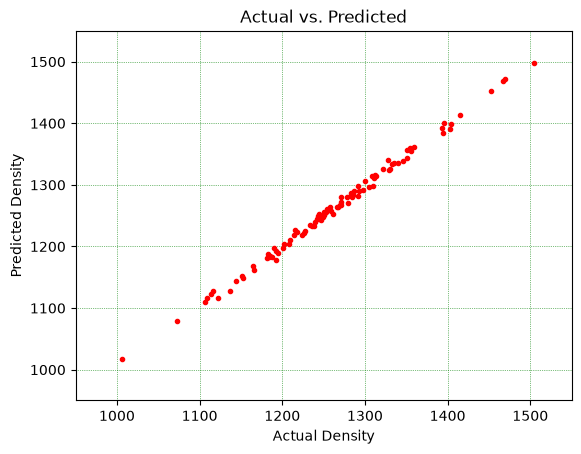

In [12]:
from chemml.visualization import scatter2D, SavePlot, decorator
import pandas as pd
%matplotlib inline
df_viz = pd.DataFrame()
df_viz["Actual"] = targets.reshape(-1,)
df_viz["Predicted"] = y_pred.reshape(-1,)
sc = scatter2D('r', marker='.')
fig = sc.plot(dfx=df_viz, dfy=df_viz, x="Actual", y="Predicted")

dec = decorator(title='Actual vs. Predicted',xlabel='Actual Density', ylabel='Predicted Density',
                xlim= (950,1550), ylim=(950,1550), grid=True, 
                grid_color='g', grid_linestyle=':', grid_linewidth=0.5)
fig = dec.fit(fig)
# print(type(fig))
sa=SavePlot(filename='Parity',output_directory='automl_results/val/images',
            kwargs={'facecolor':'w','dpi':330,'pad_inches':0.1, 'bbox_inches':'tight'})
sa.save(obj=fig)
fig.show()